# TP 4 - Entraînement et évaluation du modèle
## Mastère 2 - Data & Intelligence Artificielle


### Objectifs
1. Charger le dataset nettoyé
2. Séparer en train/test (80/20)
3. Entraîner une Régression Logistique
4. Calculer les métriques de performance
5. Créer les visualisations d'évaluation
6. Sauvegarder les modèles

### Critère de réussite
**AUC > 0.70**

## 📦 Imports

In [1]:
# Import des librairies
import os
import json
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    classification_report,
    )

# Réglages visuels
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("✅ Imports réussis")

✅ Imports réussis


---
## 📊 ÉTAPE 1 : Chargement des données

In [2]:
# Charger le dataset nettoyé
df = pd.read_csv("loan_data_clean.csv")

print(f"Dataset chargé : {df.shape}")
display(df.head())

Dataset chargé : (614, 20)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,LoanAmountToIncome,EMI,EMIToIncome,Log_LoanAmount,Log_TotalIncome,Has_Coapplicant,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0.0,1,0,5849.0,0.0,128.0,360.0,1.0,1,5849.0,0.021884,0.355556,0.000061,4.859812,8.674197,0,0,1
1,1,1,1.0,1,0,4583.0,1508.0,128.0,360.0,1.0,0,6091.0,0.021015,0.355556,0.000058,4.859812,8.714732,1,0,0
2,1,1,0.0,1,1,3000.0,0.0,66.0,360.0,1.0,1,3000.0,0.022000,0.183333,0.000061,4.204693,8.006701,0,0,1
3,1,1,0.0,0,0,2583.0,2358.0,120.0,360.0,1.0,1,4941.0,0.024287,0.333333,0.000067,4.795791,8.505525,1,0,1
4,1,0,0.0,1,0,6000.0,0.0,141.0,360.0,1.0,1,6000.0,0.023500,0.391667,0.000065,4.955827,8.699681,0,0,1


In [3]:
# Supprimer Loan_ID si elle existe
if "Loan_ID" in df.columns:
    df = df.drop(columns=["Loan_ID"])

print("Colonnes après nettoyage :")
print(df.columns.tolist())

Colonnes après nettoyage :
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'TotalIncome', 'LoanAmountToIncome', 'EMI', 'EMIToIncome', 'Log_LoanAmount', 'Log_TotalIncome', 'Has_Coapplicant', 'Property_Area_Semiurban', 'Property_Area_Urban']


---
## 🔀 ÉTAPE 2 : Séparation Train/Test

**Important** : Séparer en 80% train, 20% test avec stratification

In [4]:
# Séparer X (features) et y (cible)
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

print(f"Features (X) : {X.shape}")
print(f"Cible (y) : {y.shape}")
print("Distribution de la cible :")
print(y.value_counts(normalize=True).rename("proportion"))

Features (X) : (614, 19)
Cible (y) : (614,)
Distribution de la cible :
Loan_Status
1    0.687296
0    0.312704
Name: proportion, dtype: float64


In [5]:
# Split train/test (80/20) avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Dimensions après split :")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

Dimensions après split :
X_train: (491, 19) | X_test: (123, 19)
y_train: (491,) | y_test: (123,)


---
## 📏 ÉTAPE 3 : Normalisation

**Attention** : fit_transform sur train, transform seulement sur test !

In [6]:
# Créer et appliquer le StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Normalisation effectuée")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

✅ Normalisation effectuée
X_train_scaled: (491, 19)
X_test_scaled: (123, 19)


---
## 🤖 ÉTAPE 4 : Entraînement - Régression Logistique

In [7]:
# Créer et entraîner le modèle
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

print("✅ Régression Logistique entraînée")

✅ Régression Logistique entraînée


---
## 🎯 ÉTAPE 5 : Prédictions

In [8]:
# Faire des prédictions sur le test set
y_pred_lr = model_lr.predict(X_test_scaled)
y_pred_proba_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

print("✅ Prédictions effectuées")
print("Extrait des probabilités:", y_pred_proba_lr[:5])

✅ Prédictions effectuées
Extrait des probabilités: [0.04629866 0.91601386 0.68641976 0.84239638 0.89040154]


---
## 📊 ÉTAPE 6 : Métriques d'évaluation

Calculez : Accuracy, Precision, Recall, F1-Score, AUC

In [9]:
# Calculer toutes les métriques
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, zero_division=0)
recall = recall_score(y_test, y_pred_lr, zero_division=0)
f1 = f1_score(y_test, y_pred_lr, zero_division=0)
auc = roc_auc_score(y_test, y_pred_proba_lr)

# Afficher les résultats
print("\nMÉTRIQUES DE PERFORMANCE")
print("=" * 50)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred_lr, digits=4))


MÉTRIQUES DE PERFORMANCE
Accuracy  : 0.8618
Precision : 0.8400
Recall    : 0.9882
F1-Score  : 0.9081
AUC       : 0.8638

Classification report:
              precision    recall  f1-score   support

           0     0.9565    0.5789    0.7213        38
           1     0.8400    0.9882    0.9081        85

    accuracy                         0.8618       123
   macro avg     0.8983    0.7836    0.8147       123
weighted avg     0.8760    0.8618    0.8504       123



- Très bon résultat global: le modèle est performant avec un AUC de 0.8638 (objectif > 0.70 atteint) et un excellent rappel (0.9882), donc il détecte très bien les prêts acceptés.  
- Point à surveiller: le rappel de la classe 0 est plus faible (0.5789), ce qui indique qu’il rate encore une partie des refus.

---
## 🎲 ÉTAPE 7 : Matrice de confusion

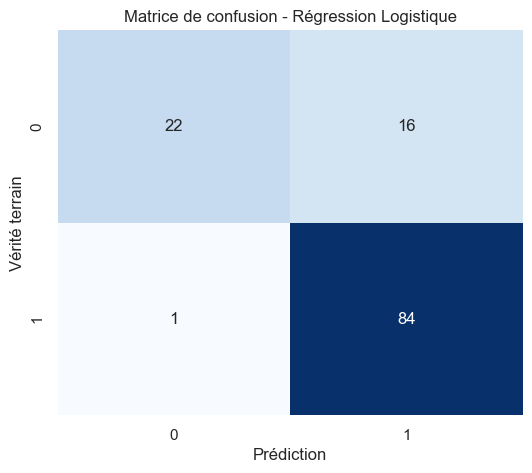

In [10]:
# Calculer et visualiser la matrice de confusion
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matrice de confusion - Régression Logistique")
plt.xlabel("Prédiction")
plt.ylabel("Vérité terrain")
plt.show()

**Commentaire :** Le modèle prédit très bien la classe 1, mais confond encore une partie des dossiers refusés (classe 0).

---
## 📈 ÉTAPE 8 : Courbe ROC

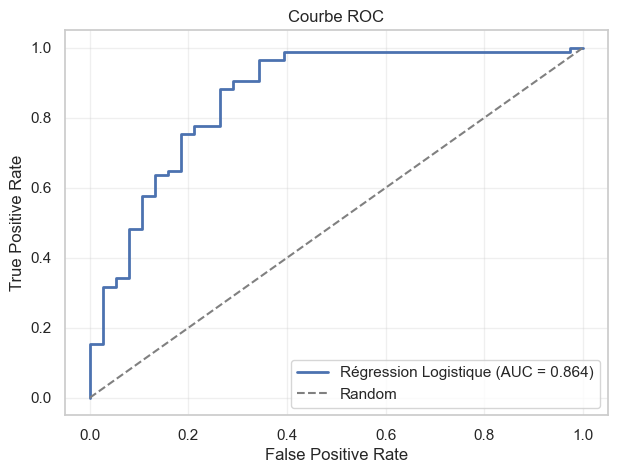

In [11]:
# Calculer et tracer la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Régression Logistique (AUC = {auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random", color="gray")
plt.title("Courbe ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**Commentaire :** La courbe ROC est nettement au-dessus de la diagonale, ce qui confirme une bonne capacité de discrimination du modèle.

---
## 🔍 ÉTAPE 9 : Feature Importance

,Feature,Coefficient,AbsCoefficient
9,Credit_History,1.272706,1.272706
13,EMIToIncome,-0.864555,0.864555
12,EMI,0.720352,0.720352
16,Has_Coapplicant,0.463084,0.463084
17,Property_Area_Semiurban,0.405574,0.405574
6,CoapplicantIncome,-0.396912,0.396912
7,LoanAmount,-0.273773,0.273773
3,Education,0.176539,0.176539
10,TotalIncome,-0.154587,0.154587
14,Log_LoanAmount,0.142554,0.142554


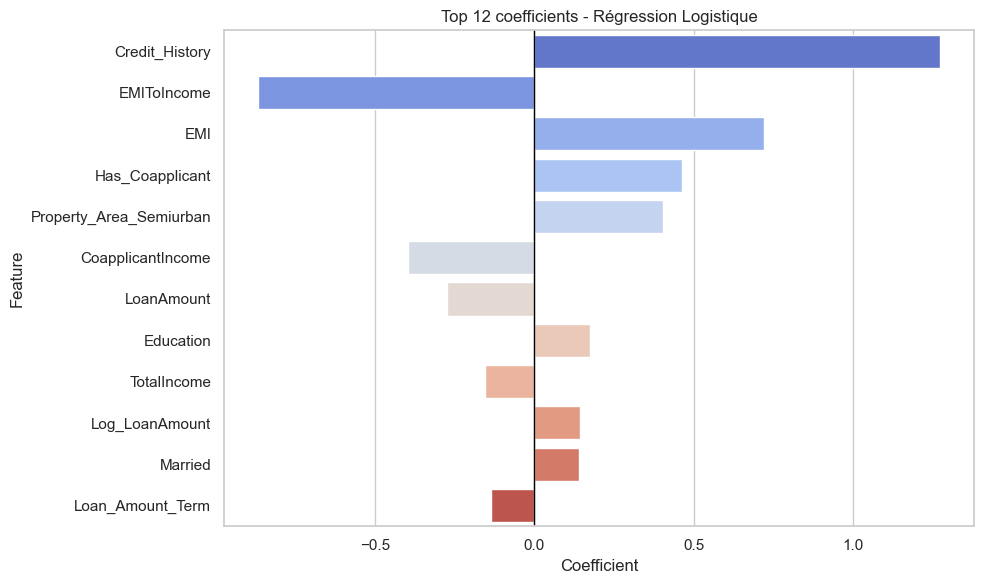

In [12]:
# Extraire et visualiser les coefficients
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_lr.coef_[0],
})
feature_importance["AbsCoefficient"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values("AbsCoefficient", ascending=False)

display(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(12),
    x="Coefficient",
    y="Feature",
    palette="coolwarm",
    hue="Feature",
    legend=False,
    )
plt.title("Top 12 coefficients - Régression Logistique")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

**Commentaire :** `Credit_History` est la variable la plus influente, suivie de variables liées à la capacité de remboursement.

---
## 🎁 BONUS : Random Forest

In [13]:
# Entraîner un Random Forest et comparer avec la Régression Logistique
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

comparison_df = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest"],
        "Accuracy": [accuracy, accuracy_rf],
        "Precision": [precision, precision_rf],
        "Recall": [recall, recall_rf],
        "F1": [f1, f1_rf],
        "AUC": [auc, auc_rf],
    }
)

print("\nComparaison des modèles")
display(comparison_df)


Comparaison des modèles


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108,0.863777
1,Random Forest,0.853659,0.876404,0.917647,0.896552,0.850774


**Commentaire :** Ici, la Régression Logistique est légèrement meilleure en AUC/F1, tandis que Random Forest montre une meilleure précision.

---
## 💾 ÉTAPE 10 : Sauvegarde des modèles

**Important** : Sauvegarder le scaler ET les modèles

In [14]:
# Créer le dossier models/
os.makedirs("models", exist_ok=True)
print("✅ Dossier models/ prêt")

✅ Dossier models/ prêt


In [15]:
# Sauvegarder le scaler
joblib.dump(scaler, "models/scaler.pkl")
print("✅ Scaler sauvegardé : models/scaler.pkl")

✅ Scaler sauvegardé : models/scaler.pkl


In [16]:
# Sauvegarder les modèles
joblib.dump(model_lr, "models/logistic_regression.pkl")
joblib.dump(model_rf, "models/random_forest.pkl")

print("✅ Modèles sauvegardés :")
print("- models/logistic_regression.pkl")
print("- models/random_forest.pkl")

✅ Modèles sauvegardés :
- models/logistic_regression.pkl
- models/random_forest.pkl


In [17]:
# (Bonus) Sauvegarder les métadonnées en JSON
metadata = {
    "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "feature_names": X.columns.tolist(),
    "train_size": int(len(X_train)),
    "test_size": int(len(X_test)),
    "metrics": {
        "logistic_regression": {
            "accuracy": float(accuracy),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "auc": float(auc),
        },
        "random_forest": {
            "accuracy": float(accuracy_rf),
            "precision": float(precision_rf),
            "recall": float(recall_rf),
            "f1": float(f1_rf),
            "auc": float(auc_rf),
        },
    },
}

with open("models/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("✅ Métadonnées sauvegardées : models/metadata.json")

✅ Métadonnées sauvegardées : models/metadata.json


In [18]:
# Tester le chargement des modèles
loaded_scaler = joblib.load("models/scaler.pkl")
loaded_model_lr = joblib.load("models/logistic_regression.pkl")

# Vérifier que les prédictions sont identiques
X_test_scaled_loaded = loaded_scaler.transform(X_test)
y_pred_loaded = loaded_model_lr.predict(X_test_scaled_loaded)

same_predictions = np.array_equal(y_pred_loaded, y_pred_lr)
print(f"Prédictions identiques après rechargement : {same_predictions}")

Prédictions identiques après rechargement : True


---
## 📝 Questions de réflexion

1. **Pourquoi séparer en train/test ? Que se passerait-il si on évaluait sur le train set ?**

2. **Quelle est la différence entre Precision et Recall ? Quel est le trade-off ?**

3. **Pourquoi l'AUC est-elle une meilleure métrique que l'Accuracy pour ce problème ?**

4. **Pourquoi est-il crucial de sauvegarder le scaler en plus du modèle ?**

5. **Entre Régression Logistique et Random Forest, lequel choisiriez-vous pour ce projet et pourquoi ?**

**Notez vos réponses ci-dessous :**

**Vos réponses :**

1. On sépare train/test pour évaluer la capacité de généralisation sur des données jamais vues. Si on évalue sur le train, on obtient un score trop optimiste (risque de surapprentissage).

2. La precision mesure la part de prédictions positives correctes, alors que le recall mesure la part des vrais positifs détectés. Le trade-off est classique : augmenter le recall peut faire baisser la precision, et inversement.

3. L'AUC est plus robuste que l'accuracy en cas de déséquilibre de classes, car elle évalue la capacité du modèle à discriminer les classes pour tous les seuils.

4. Le scaler doit être sauvegardé pour appliquer exactement la même transformation aux nouvelles données ; sinon les entrées du modèle changent et les prédictions deviennent incohérentes.

5. Je choisirais la Régression Logistique ici : performances légèrement meilleures (AUC/F1), modèle plus simple, plus interprétable et plus facile à maintenir.

In [20]:
# Résumé automatique des performances
summary = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1", "AUC"],
        "Logistic Regression": [accuracy, precision, recall, f1, auc],
        "Random Forest": [accuracy_rf, precision_rf, recall_rf, f1_rf, auc_rf],
    }
)
display(summary.round(4))

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.8618,0.8537
1,Precision,0.8400,0.8764
2,Recall,0.9882,0.9176
3,F1,0.9081,0.8966
4,AUC,0.8638,0.8508


- La Régression Logistique est globalement meilleure (Accuracy, Recall, F1, AUC), tandis que Random Forest n’est meilleure qu’en Precision.  
- Si l’objectif est de ne pas rater des prêts à approuver, la Régression Logistique est le meilleur choix ici.

In [21]:
# Vérification du critère de réussite
threshold = 0.70
is_success = auc > threshold
print(f"AUC obtenue (LR): {auc:.4f}")
print(f"Critère AUC > {threshold:.2f} validé : {is_success}")

AUC obtenue (LR): 0.8638
Critère AUC > 0.70 validé : True
